In [2]:
import os
import duckdb

duckdb_path = os.getenv("DUCKDB_PATH")
assert duckdb_path is not None, "Variable 'DUCKDB_PATH' must be defined"

con = duckdb.connect(duckdb_path)
con.sql("SELECT * FROM INFORMATION_SCHEMA.TABLES;").df()

,table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action,TABLE_COMMENT
0,legislative,main,deputados,BASE TABLE,None,None,None,None,None,YES,NO,None,None
1,legislative,main,proposicoesTemas,BASE TABLE,None,None,None,None,None,YES,NO,None,None
2,legislative,main,votacoesObjetos,BASE TABLE,None,None,None,None,None,YES,NO,None,None
3,legislative,main,votacoesVotos,BASE TABLE,None,None,None,None,None,YES,NO,None,None
4,legislative,main,deputies_propositions,VIEW,None,None,None,None,None,NO,NO,None,None


In [3]:
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
import statistics

# Old

In [4]:
deputies_votes_grouped_themes_query = open("../queries/deputies_votes_grouped_themes.sql").read()

def query_votes_by_grouped_themes(theme_codes: list[int]):
    return con.execute(deputies_votes_grouped_themes_query, [theme_codes]).df()

In [5]:
themes = [34]

votes = query_votes_by_grouped_themes(themes)

votes

,deputado_id,votacao_id,voto
0,d_220593,v_2345484-83,Sim
1,d_204379,v_2345484-83,Não
2,d_221328,v_2345484-83,Sim
3,d_204528,v_2345484-83,Não
4,d_121948,v_2345484-83,Não
...,...,...,...
16161,d_220660,v_2466104-97,Não
16162,d_220558,v_2466104-97,Sim
16163,d_160592,v_2466104-97,Não
16164,d_220592,v_2466104-97,Sim


In [7]:
G = nx.from_pandas_edgelist(votes, source='deputado_id', target='votacao_id', edge_attr='voto')

## Creating attribute-filled deputies graph

In [52]:
deputies_attrs = con.execute("""
    SELECT DISTINCT
        CONCAT('d_', vv.deputado_id) as node_id,
        vv.deputado_nome as nome,
        vv.deputado_siglaPartido as partido,
        vv.deputado_siglaUf as uf
    FROM votacoesVotos vv
    INNER JOIN (
        SELECT
            deputado_id,
            MAX(dataHoraVoto) as ultima_votacao
        FROM votacoesVotos
        GROUP BY deputado_id
    ) ultimo on vv.deputado_id = ultimo.deputado_id
        AND vv.dataHoraVoto = ultimo.ultima_votacao
""").df()

In [53]:
deputies_attrs

,node_id,nome,partido,uf
0,d_220008,Eliza Virgínia,PP,PB
1,d_73806,Roseana Sarney,MDB,MA
2,d_213274,Ricardo Silva,PSD,SP
3,d_73788,Ricardo Barros,PP,PR
4,d_220661,Matheus Noronha,PL,CE
...,...,...,...,...
616,d_160508,Afonso Florence,PT,BA
617,d_204517,Zé Vitor,PL,MG
618,d_220692,Dal Barreto,UNIÃO,BA
619,d_204507,Carla Zambelli,PL,SP


In [57]:
attrs = deputies_attrs.set_index('node_id').to_dict('index')

In [37]:
nx.set_node_attributes(G, attrs)

In [38]:
nx.write_gexf(G, '../graphs/deputy_votes.gexf')

## Creating the projection

In [43]:
deputies_nodes, polls_nodes = nx.bipartite.sets(G)

In [45]:
def signed_weighted_projection(B, deputies):
    G_proj = nx.Graph()
    G_proj.add_nodes_from(deputies)

    for u, v in nx.bipartite.weighted_projected_graph(B, deputies).edges():
        common_votes = list(nx.common_neighbors(B, u, v))

        if not common_votes:
            continue

        agreeCount = 0
        disagreeCount = 0

        for vote in common_votes:
            vote_u = B[u][vote]['voto']
            vote_v = B[v][vote]['voto']

            if vote_u == vote_v:
                agreeCount += 1
            else:
                disagreeCount += 1

        total = agreeCount + disagreeCount
        weight = (agreeCount - disagreeCount) / total

        G_proj.add_edge(u, v, weight=weight)

    return G_proj

In [56]:
G_proj = signed_weighted_projection(G, deputies_nodes)

In [58]:
nx.set_node_attributes(G_proj, attrs)

In [59]:
nx.write_gexf(G_proj, '../graphs/deputy_projection.gexf')

# Create a projection for each theme (with enough polls)

## Steps
1. Select the code and name of each theme
2. Create the deputies-vote relation graph for each theme
3. Create the deputies agreement projections from the relation graphs

### Select themes code and name

In [7]:
themes = con.execute("""
    SELECT
        pt.codTema as code,
        pt.tema as theme,
        COALESCE(SUM(pp.polls_count), 0)::INT as polls_count
    FROM proposicoesTemas pt
    LEFT JOIN (
        SELECT
            vo.proposicao_id,
            COUNT(vo.idVotacao) as polls_count
        FROM votacoesObjetos vo
        JOIN votacoesVotos vv ON vv.idVotacao = vo.idVotacao
        GROUP BY vo.proposicao_id
    ) pp ON pp.proposicao_id = pt.proposicao_id
    GROUP BY 1, 2
    ORDER BY 3 DESC
""").df()

themes

,code,theme,polls_count
0,34,Administração Pública,16661
1,70,Finanças Públicas e Orçamento,11161
2,40,Economia,6431
3,51,Estrutura Fundiária,3946
4,44,Direitos Humanos e Minorias,3126
5,67,Direito e Defesa do Consumidor,3126
6,54,"Energia, Recursos Hídricos e Minerais",3126
7,42,Direito Civil e Processual Civil,2901
8,66,"Indústria, Comércio e Serviços",2370
9,56,Saúde,2011


### Select only voted themes

In [8]:
voted_themes = themes[themes['polls_count'] > 0]

voted_themes

,code,theme,polls_count
0,34,Administração Pública,16661
1,70,Finanças Públicas e Orçamento,11161
2,40,Economia,6431
3,51,Estrutura Fundiária,3946
4,44,Direitos Humanos e Minorias,3126
5,67,Direito e Defesa do Consumidor,3126
6,54,"Energia, Recursos Hídricos e Minerais",3126
7,42,Direito Civil e Processual Civil,2901
8,66,"Indústria, Comércio e Serviços",2370
9,56,Saúde,2011


### Create deputy-votes graph for each theme

#### Select deputies votes for each theme

In [93]:
def select_deputies_votes_per_theme(code_theme: int):
    deputies_votes = con.execute("""
        SELECT
          CONCAT('d_', vv.deputado_id) AS deputado_id,
          CONCAT('v_', vv.idVotacao) AS votacao_id,
          vv.voto
        FROM votacoesVotos vv
        WHERE vv.voto IN ('Sim', 'Não')
          AND vv.idVotacao IN (
            SELECT DISTINCT vo.idVotacao
            FROM votacoesObjetos vo
            JOIN proposicoesTemas pt ON vo.proposicao_id = pt.proposicao_id
            WHERE pt.codTema = ?
          )
    """, [code_theme]).df()

    return deputies_votes

#### Save attributes for graph filtering

In [3]:
deputies_info = con.execute("""
    SELECT DISTINCT
        CONCAT('d_', vv.deputado_id) as node_id,
        vv.deputado_nome as nome,
        vv.deputado_siglaPartido as partido,
        vv.deputado_siglaUf as uf
    FROM votacoesVotos vv
    INNER JOIN (
        SELECT
            deputado_id,
            MAX(dataHoraVoto) as ultima_votacao
        FROM votacoesVotos
        GROUP BY deputado_id
    ) ultimo on vv.deputado_id = ultimo.deputado_id
        AND vv.dataHoraVoto = ultimo.ultima_votacao
""").df()

deputies_attrs = deputies_info.set_index('node_id').to_dict('index')

deputies_attrs

{'d_234673': {'nome': 'Vanderlan Alves', 'partido': 'UNIÃO', 'uf': 'CE'},
 'd_233598': {'nome': 'Samuel Santos', 'partido': 'PODE', 'uf': 'GO'},
 'd_178937': {'nome': 'Altineu Côrtes', 'partido': 'PL', 'uf': 'RJ'},
 'd_233592': {'nome': 'Paulo Lemos', 'partido': 'PSOL', 'uf': 'AP'},
 'd_229106': {'nome': 'Carla Ayres', 'partido': 'PT', 'uf': 'SC'},
 'd_227275': {'nome': 'Mariana Carvalho',
  'partido': 'REPUBLICANOS',
  'uf': 'MA'},
 'd_128760': {'nome': 'Paulo Marinho Jr', 'partido': 'PL', 'uf': 'MA'},
 'd_227800': {'nome': 'Duarte Gonçalves Jr',
  'partido': 'REPUBLICANOS',
  'uf': 'MG'},
 'd_228837': {'nome': 'Juliana Kolankiewicz', 'partido': 'MDB', 'uf': 'MT'},
 'd_74095': {'nome': 'Pauderney Avelino', 'partido': 'UNIÃO', 'uf': 'AM'},
 'd_141391': {'nome': 'Arnaldo Jardim', 'partido': 'CIDADANIA', 'uf': 'SP'},
 'd_62881': {'nome': 'Danilo Forte', 'partido': 'UNIÃO', 'uf': 'CE'},
 'd_234406': {'nome': 'Elmano Férrer', 'partido': 'PP', 'uf': 'PI'},
 'd_220651': {'nome': 'Simone Marq

#### Create graph for each theme

In [102]:
for theme in voted_themes.itertuples():
    code_theme = theme.code
    
    deputies_votes = select_deputies_votes_per_theme(code_theme)

    G = nx.from_pandas_edgelist(deputies_votes, source='deputado_id', target='votacao_id', edge_attr='voto')

    nx.set_node_attributes(G, deputies_attrs)

    nx.write_gexf(G, f'../graphs/theme_votes/votes_{code_theme}.gexf')

#### Create normalized projection for each graph

In [9]:
def generate_normalized_projection(B: nx.classes.graph.Graph, deputies: set):
    votes_nodes = [n for n in B.nodes() if n not in deputies]

    deputy_idx = {d: i for i, d in enumerate(deputies)}
    vote_idx = {v: i for i, v in enumerate(votes_nodes)}

    vote_matrix = np.full((len(deputies), len(votes_nodes)), np.nan)

    for deputy_id in deputies:
        d_i = deputy_idx[deputy_id]
        for vote in B.neighbors(deputy_id):
            if vote in vote_idx:
                vote_matrix[d_i, vote_idx[vote]] = 1 if B[deputy_id][vote]['voto'] == 'Sim' else 0

    G_proj = nx.Graph()
    G_proj.add_nodes_from(deputies)

    for u, v in nx.bipartite.projected_graph(B, deputies).edges():
        row_u = vote_matrix[deputy_idx[u]]
        row_v = vote_matrix[deputy_idx[v]]

        common_mask = ~np.isnan(row_u) & ~np.isnan(row_v)

        if not np.any(common_mask):
            continue

        u_votes = row_u[common_mask]
        v_votes = row_v[common_mask]

        agree = np.sum(u_votes == v_votes)
        disagree = np.sum(u_votes != v_votes)
        total = agree + disagree

        G_proj.add_edge(u, v, weight=(agree - disagree) / total)

    return G_proj

In [10]:
from pathlib import Path

In [ ]:
for theme in voted_themes.itertuples():
    code_theme = theme.code

    file_path = Path(f'../graphs/theme_projections/projection_{code_theme}.gexf')
    if file_path.exists():
        continue
    
    G = nx.read_gexf(f'../graphs/theme_votes/votes_{code_theme}.gexf')
    
    deputies_nodes, _ = nx.bipartite.sets(G)
    
    G_proj = generate_normalized_projection(G, deputies_nodes)
    
    nx.set_node_attributes(G_proj, deputies_attrs)
    
    nx.write_gexf(G_proj, f'../graphs/theme_projections/projection_{code_theme}.gexf')

### Improve Visualization

The way the projections are being built, there is not format standard. That way, we cannot compare agreements distribution across themes.

We need to set a default position for each deputy that remains across every projection.

Ordering by political party can make not conventinal distributions show up more easily.

#### Select every deputy party

In [14]:
deputies_attrs = con.execute("""
    SELECT DISTINCT
        CONCAT('d_', vv.deputado_id) as node_id,
        vv.deputado_nome as nome,
        vv.deputado_siglaPartido as partido,
        vv.deputado_siglaUf as uf
    FROM votacoesVotos vv
    INNER JOIN (
        SELECT
            deputado_id,
            MAX(dataHoraVoto) as ultima_votacao
        FROM votacoesVotos
        GROUP BY deputado_id
    ) ultimo on vv.deputado_id = ultimo.deputado_id
        AND vv.dataHoraVoto = ultimo.ultima_votacao
""").df()

deputies_attrs

,node_id,nome,partido,uf
0,d_229082,Lucyana Genésio,PDT,MA
1,d_89536,Prof. Paulo Fernando,REPUBLICANOS,DF
2,d_220539,Defensor Stélio Dener,REPUBLICANOS,RR
3,d_204374,Bia Kicis,PL,DF
4,d_220691,Diego Coronel,PSD,BA
...,...,...,...,...
616,d_175765,Ribamar Silva,PSD,SP
617,d_204360,Silvia Cristina,PP,RO
618,d_220660,Yury do Paredão,MDB,CE
619,d_178829,Capitão Augusto,PL,SP


In [15]:
attrs = deputies_attrs.set_index('node_id').to_dict('index')

#### Create default positions

In [16]:
ordered_deputies_nodes = sorted(attrs, key=lambda n: attrs[n].get('partido', ''))

In [17]:
pos = nx.circular_layout(ordered_deputies_nodes)

In [104]:
for theme in voted_themes.itertuples():
    code_theme = theme.code

    file_path = Path(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')
    if file_path.exists():
        continue

    G = nx.read_gexf(f'../graphs/theme_projections/projection_{code_theme}.gexf')

    for node, (x, y) in pos.items():
        if node in G:
            G.nodes[node]['x'] = float(x)
            G.nodes[node]['y'] = float(y)

    bc = nx.betweenness_centrality(G, weight='weight', normalized=True)
    nx.set_node_attributes(G, bc, 'betweenness')

    nx.write_gexf(G, f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

#### Correção no cálculo de betweenness

A existência de pesos negativos afeta o funcionamento do algorítmo de Dijkstra, usado como algorítmo de cálculo do betweenness.

Duas abordagens existem para isso:
- Considerar os valores absolutos do peso das arestas
- Descosiderar arestas com peso negativo

As duas opções podem trazer algum tipo de diagnóstico sobre a dinâmica dos deputados. Porém, como objetivamos encontrar deputados que são "pontes" de negociação entre lados opostos, seguimos com a segunda opção.

In [25]:
for theme in voted_themes.itertuples():
    code_theme = theme.code

    file_path = Path(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')
    if file_path.exists():
        continue

    G = nx.read_gexf(f'../graphs/theme_projections/projection_{code_theme}.gexf')

    for node, (x, y) in pos.items():
        if node in G:
            G.nodes[node]['x'] = float(x)
            G.nodes[node]['y'] = float(y)

    positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    G_positive = nx.Graph()
    G_positive.add_nodes_from(G.nodes(data=True))
    G_positive.add_edges_from(positive_edges)

    bc = nx.betweenness_centrality(G_positive, weight='weight', normalized=True)
    nx.set_node_attributes(G, bc, 'betweenness')

    nx.write_gexf(G, f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

### Metrics

In [21]:
theme_attrs = voted_themes.set_index('code').to_dict('index')

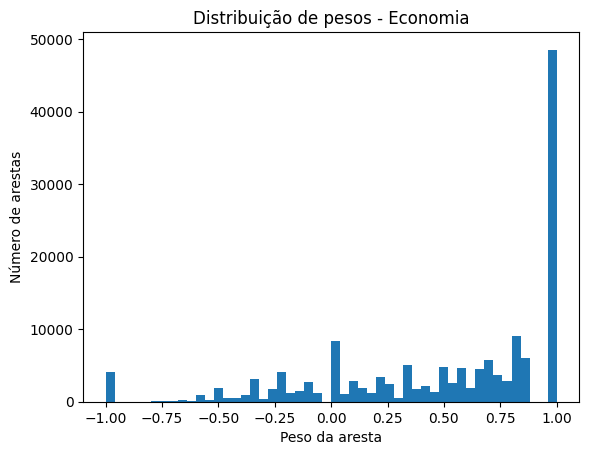

In [67]:
code_theme = 40

G = nx.read_gexf(f'../graphs/theme_projections/projection_{code_theme}.gexf')

weights = [d['weight'] for u, v, d in G.edges(data=True)]
plt.hist(weights, bins=50)
plt.xlabel('Peso da aresta')
plt.ylabel('Número de arestas')
plt.title(f'Distribuição de pesos - {theme_attrs[code_theme]["theme"]}')
plt.show()

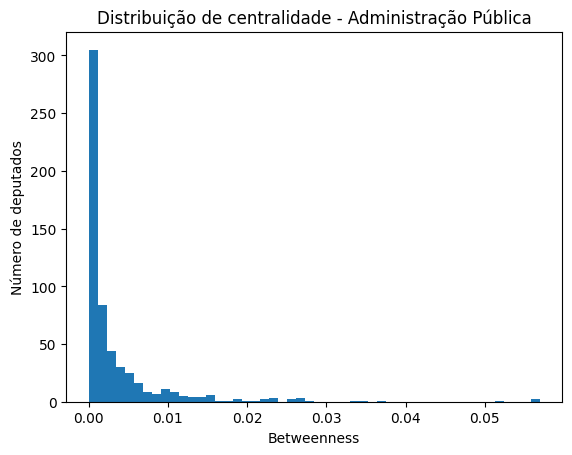

In [32]:
code_theme = 34

G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

betweennesses = [d[1]['betweenness'] for d in G.nodes(data=True)]
plt.hist(betweennesses, bins=50)
plt.xlabel('Betweenness')
plt.ylabel('Número de deputados')
plt.title(f'Distribuição de centralidade - {theme_attrs[code_theme]["theme"]}')
plt.show()

In [34]:
G.degree('d_160552')

548

In [35]:
threshold = 0.05
high_betweenness_nodes = [
    (node, data) for node, data in G.nodes(data=True) 
    if data.get("betweenness", float("-inf")) > threshold
]

for node, data in high_betweenness_nodes:
    print(data.get("nome"))

Luiz Carlos Motta
Beto Richa
Antonio Carlos Rodrigues


#### Edge Weigth Mean

Since betweenness did not help us to find any relevat "bridge" deputy, what is normal for highly dense graphs, lets get the edge weigh mean to identify which deputies are:
-  Ideologically coese (Low mean)
-  More fluid (High mean)

In [36]:
avg_weight = {node: np.mean([d['weight'] for _, _, d in G.edges(node, data=True)]) for node in G.nodes()}

In [45]:
avg_weight_values = np.array(list(avg_weight.values()))

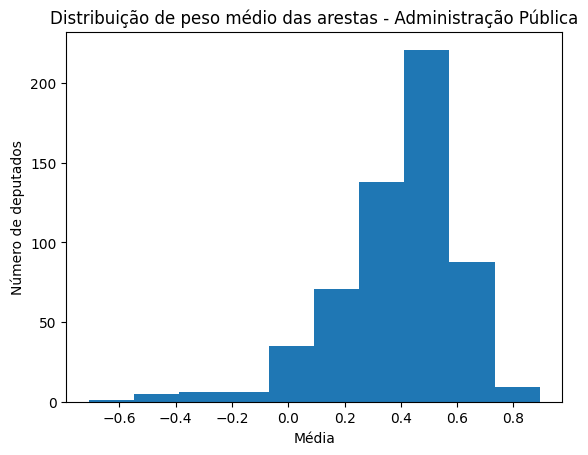

In [47]:
plt.hist(avg_weight_values)
plt.xlabel('Média')
plt.ylabel('Número de deputados')
plt.title(f'Distribuição de peso médio das arestas - {theme_attrs[code_theme]["theme"]}')
plt.show()